# 05 · Virtual Z, the SU(3) decomposition, the 216 Cliffords and a qutrit Hadamard

The theory half of the 2022 shop. To run *any* single-qutrit gate we need (i) rotations about any equatorial axis of each subspace —
obtained for free by shifting the phase of the drive ("virtual Z"), (ii) a recipe that turns an arbitrary 3×3 unitary into a few
such rotations, and (iii) a test gate. The test gate was the qutrit Hadamard $H_3$ (the 3-point discrete Fourier transform),
the recipe was worked out by hand in `su3_decomposition.ipynb` and checked numerically in `Clifford/probe.ipynb`, and the whole
Clifford group was generated so that randomized benchmarking (notebook 06) could follow.

Everything here is in `pulseshop.qutrit`, `pulseshop.su3` and `pulseshop.clifford`.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from pulseshop import qutrit as Q, su3, clifford, readout, io
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
pi = np.pi
np.set_printoptions(precision=3, suppress=True)

## 1. The virtual-Z identity for qutrit subspaces (`Gell-Mann/VZ-proof.ipynb`)

For a qubit, $Z(\phi)\,X(\theta)\,Z(-\phi) = \exp[-i\tfrac{\theta}{2}(\cos\phi\,\sigma_x + \sin\phi\,\sigma_y)]$: a phase shift of the
drive rotates the axis. The 2022 sympy proof showed the same holds inside each subspace of a qutrit with the Gell-Mann generators
$\lambda_{1,2}$ (0–1) and $\lambda_{6,7}$ (1–2), *provided* the Z generator is the subspace one (diag(1,−1,0) or diag(0,1,−1)).
Numerically:

In [2]:
theta, phi = 0.73, 2.1
lhs01 = Q.R01(theta, phi)
rhs01 = expm(-1j * theta / 2 * (np.cos(phi) * Q.Lx01 + np.sin(phi) * Q.Ly01))
lhs12 = Q.R12(theta, phi)
rhs12 = expm(-1j * theta / 2 * (np.cos(phi) * Q.Lx12 + np.sin(phi) * Q.Ly12))
print("0-1 subspace identity holds:", np.allclose(lhs01, rhs01))
print("1-2 subspace identity holds:", np.allclose(lhs12, rhs12))
print("R01(theta, phi) =\n", lhs01)

0-1 subspace identity holds: True
1-2 subspace identity holds: True
R01(theta, phi) =
 [[ 0.934+0.j   -0.308+0.18j  0.   +0.j  ]
 [ 0.308+0.18j  0.934+0.j    0.   +0.j  ]
 [ 0.   +0.j    0.   +0.j    1.   +0.j  ]]


On the hardware the phase shift is `pulse.phase_offset(phi, channel)` around the pulse (`Virtual-Z/vz.ipynb` checked that, unlike
`shift_phase`, a `phase_offset` block leaves the frame of the *following* pulses intact). The subtlety that fills notebooks 07–08:
a phase offset on the 0–1 drive does not touch the 1–2 frame, but a *physical* 0–1 pulse does.

## 2. Decomposing a qutrit unitary into three pulses (`su3_decomposition.ipynb`, `Clifford/probe.ipynb`)

$$U = U_d(\phi_6,\phi_5,\phi_4)\; R_{01}(\theta_3,\phi_3)\; R_{12}(\theta_2,\phi_2)\; R_{01}(\theta_1,\phi_1)$$

with $U_d$ a diagonal phase gate absorbed into the drive frames. `su3.get_parameter` extracts the nine angles analytically
(special cases when $|U_{33}| = 1$ or $0$), `su3.reconstruct` rebuilds the matrix.

In [3]:
H3 = clifford.H3
angles = su3.get_parameter(H3)
print("angles (theta1, theta2, theta3, phi1..phi6) for H3:", np.round(angles, 4))
print("reconstruction error:", np.abs(su3.reconstruct(*angles) - H3).max())
print("2022 csv first row (Hadamard):", np.round(io.load_csv("lab_2022", "clifford_parameter_2022.csv")[0], 4))

angles (theta1, theta2, theta3, phi1..phi6) for H3: [ 1.571  1.911  1.571 -2.618 -2.618 -1.047  2.094 -3.142 -6.807]
reconstruction error: 4.726910484514079e-07
2022 csv first row (Hadamard): [ 1.571  1.911  1.571 -2.618 -2.618 -1.047  2.094 -3.142 -6.807]


The Hadamard needs $\theta = (\pi/2,\ 1.9106,\ \pi/2)$ — two $\pi/2$ pulses on 0–1 around a 1–2 rotation by $2\arccos(1/\sqrt3)$ — the
three-pulse schedule that `OneH3.ipynb` played on `ibm_oslo` in August 2022.

## 3. The 216 single-qutrit Cliffords (`rb/clifford_gen.ipynb`)

Words in $\{H, S\}$ up to length 12, duplicates removed, duplicates up to a global phase removed. (About 20 s.)

In [4]:
C3 = clifford.generate_clifford3()
print(len(C3), "Cliffords")
saved = io.load_npy("shop_2023_legacy/rb/data", "Clifford3_unique.npy")
print("identical (up to phase, same order) to rb/data/Clifford3_unique.pkl of 2024 (now .npy):", all(su3.is_global_phase(a, b) for a, b in zip(C3, saved)))
params = su3.decompose_all(C3)
print("elements whose decomposition fails to reconstruct them:", su3.find_bug(C3, params))
inv = clifford.inverse_table(C3)
print("every element has an inverse in the table:", bool((inv >= 0).all()), "| self-inverse elements:", int(np.sum(inv == np.arange(216))))

216 Cliffords
identical (up to phase, same order) to rb/data/Clifford3_unique.pkl of 2024 (now .npy): True
elements whose decomposition fails to reconstruct them: []


every element has an inverse in the table: True | self-inverse elements: 10


### A bug the 2022 notebook did not catch

`Clifford/probe.ipynb` printed *"No bug whatsoever!"* and wrote `clifford_parameter.csv`. Its `find_bug()` loop, however, only
compared the **last** element (the `if` sits outside the `for`). Re-checking the 2022 table against the group:

In [5]:
csv22 = io.load_csv("lab_2022", "clifford_parameter_2022.csv")
ok = [clifford.find_index(su3.reconstruct(*row), C3) >= 0 for row in csv22]
print(f"rows of the 2022 table that reconstruct a Clifford: {sum(ok)} / 216  (row 0, the Hadamard, is correct)")

rows of the 2022 table that reconstruct a Clifford: 31 / 216  (row 0, the Hadamard, is correct)


Only the Hadamard (row 0) was ever used experimentally, so the 2022 experiments are unaffected; the 2023 RB work regenerated the table
(`clifford_parameter_update.csv`, with a corrected `find_bug`; that file did not survive), which is what `pulseshop.su3` reproduces: 216/216.

## 4. Distribution of pulse angles over the group

Useful for pulse budgets: how many of the 216 gates need all three pulses?

number of non-zero rotation angles per Clifford: {0: 9, 1: 18, 2: 18, 3: 171}


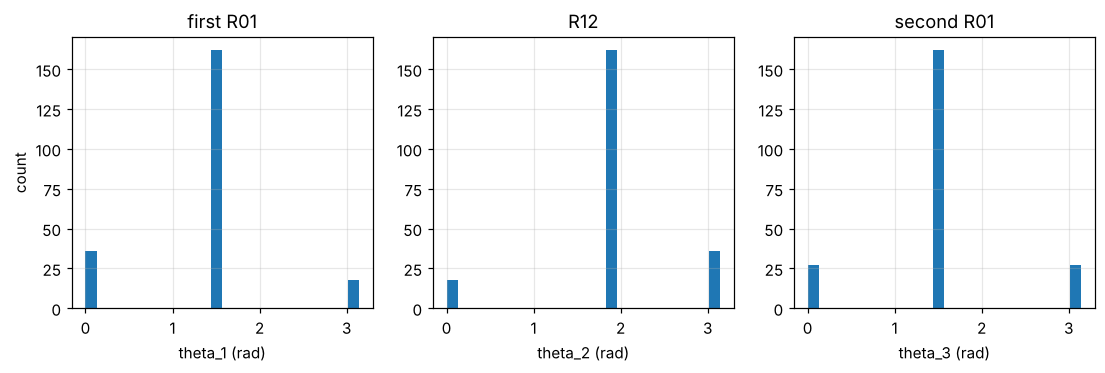

In [6]:
th = params[:, :3]
nontrivial = (np.abs(th) > 1e-6).sum(axis=1)
print("number of non-zero rotation angles per Clifford:", {k: int(np.sum(nontrivial == k)) for k in range(4)})
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
for k, ax in enumerate(axes):
    ax.hist(th[:, k], bins=24, range=(0, pi))
    ax.set(xlabel=f"theta_{k+1} (rad)", title=["first R01", "R12", "second R01"][k])
axes[0].set_ylabel("count")
io.save_fig(fig, "05_clifford_angle_histograms")

## 5. The Hadamard on `ibm_oslo` (Aug 2022)

`discr.ipynb` (25 Aug) played the three-pulse $H_3$ once on |0⟩ and counted 6178 : 6794 : 7028 of 20 000 shots with the LDA of
notebook 02; `TwoH3.ipynb` (26 Aug) then played one and two $H_3$ with the frame phases of the second carried over
($\phi_{01} \mathrel{+}= \phi_4-\phi_5$, $\phi_{12} \mathrel{+}= \phi_6-\phi_5$). The two csv files that survive (`discr_data.csv`, `two_h3_data.csv`) hold the calibration shots of
each day (the experiment shots of the 26 Aug job were never written to disk, and the notebook's `count()` had an indexing bug that made its
three printed results identical). The two files are kept as `.npy` under `data/lab_2022/`. What can be checked today:

* the ideal predictions, $H_3|0\rangle = (|0\rangle+|1\rangle+|2\rangle)/\sqrt3$ and $H_3^2|0\rangle = |0\rangle$ ($H_3^2$ is the permutation $|k\rangle\to|{-k}\rangle$);
* the single-$H_3$ counts of 25 Aug, mitigated with that day's confusion matrix;
* how stable the readout was from one day to the next.

In [7]:
discr25 = io.load_npy("lab_2022", "oslo_2022-08-25_discriminator_shots.npy")
discr26 = io.load_npy("lab_2022", "oslo_2022-08-26_two_h3_shots.npy")      # calibration circuits of the TwoH3 job
ideal = [Q.populations(H3 @ Q.ket0), Q.populations(H3 @ H3 @ Q.ket0)]
print("ideal H3|0>:", np.round(ideal[0], 3), "  ideal H3 H3|0>:", np.round(ideal[1], 3))
lda25 = readout.LDADiscriminator(random_state=0).fit(discr25)
cm25 = readout.confusion_matrix(discr25, lda25)
counts_h3 = np.array([6178, 6794, 7028]) / 20000
print("single H3, 25 Aug: raw", counts_h3, " mitigated", np.round(readout.mitigated_population(counts_h3, cm25), 3))
cm26 = readout.confusion_matrix(discr26, readout.LDADiscriminator(random_state=0).fit(discr26))
print("readout fidelity diag, 25 Aug:", np.round(np.diag(cm25), 3), " 26 Aug:", np.round(np.diag(cm26), 3))

ideal H3|0>: [0.333 0.333 0.333]   ideal H3 H3|0>: [1. 0. 0.]
single H3, 25 Aug: raw [0.309 0.34  0.351]  mitigated [0.323 0.337 0.34 ]
readout fidelity diag, 25 Aug: [0.931 0.962 0.954]  26 Aug: [0.904 0.958 0.953]


A single $H_3$ gives populations within 0.03 of the ideal thirds. Two $H_3$ should return to |0⟩; how well they do depends on the frame
phases between the two gates — the question that grew into the phase-tracking programme of notebook 07 (and, with randomized
benchmarking of the same Hadamard on `ibm_lagos`, notebook 06: $p = 0.964$ per interleaved $H_3$).

In [8]:
seq = clifford.rb_sequence(3, C3, inv, np.random.default_rng(0))
pulses, frames = clifford.pulse_sequence_phases([params[i] for i in seq], alpha=0.61, beta=0.73, gamma=6.24)
print("Clifford indices:", seq, "| ideal final populations:", np.round(clifford.ideal_sequence_populations(seq, C3), 3))
for sub, th_, ph_ in pulses:
    print(f"  R{sub}(theta = {th_:5.3f}, phi = {ph_:7.3f})")
print("frame phases left behind (phase_01, phase_12):", np.round(frames, 3))

Clifford indices: [183 137 110  30] | ideal final populations: [1. 0. 0.]
  R01(theta = 1.571, phi =  -0.524)
  R12(theta = 1.911, phi =   4.275)
  R01(theta = 1.571, phi =   1.777)
  R01(theta = 1.571, phi =   2.824)
  R12(theta = 1.911, phi =  12.782)
  R01(theta = 1.571, phi =   5.125)
  R01(theta = 1.571, phi =   1.984)
  R12(theta = 1.911, phi =  23.384)
  R01(theta = 1.571, phi =   4.284)
  R01(theta = 1.571, phi =   5.332)
  R12(theta = 1.911, phi =  31.891)
  R01(theta = 1.571, phi =   7.632)
frame phases left behind (phase_01, phase_12): [ 5.014 38.218]
